# Baseline Pricing Strategies

## Objective

Before training a Reinforcement Learning agent, it is important to establish baseline strategies.

These heuristic approaches provide reference performance against which the RL agent will later be evaluated.

The following baseline strategies are implemented:

1. Fixed Price Strategy
2. Time-Based Discount Strategy

The total revenue generated by these strategies will serve as a benchmark for future comparison.

In [5]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print("Project Root:", PROJECT_ROOT)

Project Root: d:\Live Master\Projects\travel-dynamic-pricing-rl


In [6]:
from src.baseline_agents import FixedPriceAgent, TimeDiscountAgent

from src.evaluate import run_episode

fixed = FixedPriceAgent()
discount = TimeDiscountAgent()

print("Fixed Strategy Revenue:", run_episode(fixed))
print("Time Discount Revenue:", run_episode(discount))

Fixed Strategy Revenue: 1300
Time Discount Revenue: 1980


## Observations

The two heuristic pricing strategies establish baseline performance.

- The Fixed Price Strategy maintains a constant ticket price throughout the booking season.
- The Time-Based Discount Strategy gradually lowers prices as the departure date approaches.

These strategies do not learn from experience and therefore cannot adapt to different market conditions. Their performance will later be compared against Q-Learning and Deep Q-Network (DQN) agents.

# Q-Learning

## Objective

Q-Learning is a model-free reinforcement learning algorithm that learns the expected future reward for taking an action in a given state.

Unlike the heuristic baseline strategies, the Q-Learning agent improves its pricing policy through repeated interactions with the environment.

The agent learns a Q-table that stores the expected cumulative reward for every state-action pair.

In [7]:
from src.q_learning import QLearningAgent

agent = QLearningAgent()

print(agent.q_table.shape)

state = (50, 30)

for _ in range(5):
    print(agent.choose_action(state))

(51, 31, 5)
4
3
4
3
0


## Exploration vs. Exploitation

The agent follows an epsilon-greedy policy.

- With probability ε, it explores by selecting a random action.
- With probability (1 − ε), it exploits the current knowledge by selecting the action with the highest Q-value.

Initially, ε is set to 1.0 to encourage exploration. It will gradually decrease during training to allow the agent to exploit learned knowledge.

## Bellman Update Equation

The Q-Learning algorithm updates its knowledge using the Bellman equation.

\[
Q(s,a) \leftarrow Q(s,a) + \alpha
\left[
r + \gamma \max_a Q(s',a) - Q(s,a)
\right]
\]

where:

- \(Q(s,a)\) is the current estimate.
- \(r\) is the immediate reward.
- \(\gamma\) is the discount factor.
- \(\alpha\) is the learning rate.
- \(s'\) is the next state.

Over many episodes, the Q-table converges toward the optimal pricing policy.

In [8]:
from src.environment import DynamicPricingEnv
from src.q_learning import QLearningAgent

env = DynamicPricingEnv()
agent = QLearningAgent()

print("Initial Epsilon:", agent.epsilon)

Initial Epsilon: 1.0


## Training the Q-Learning Agent

The Q-Learning agent interacts with the environment over multiple simulated booking seasons.

During training:

- The agent selects actions using an epsilon-greedy policy.
- The Q-table is updated after every interaction using the Bellman equation.
- The exploration rate (ε) gradually decreases, allowing the agent to shift from exploration to exploitation.

## Evaluating the Learned Policy

After training, the learned Q-table is evaluated without exploration.

The agent always selects the action with the highest learned Q-value for each state.

The resulting revenue is compared with the heuristic baseline strategies to determine whether reinforcement learning provides an improvement.

In [9]:
import numpy as np

from src.q_learning import QLearningAgent
from src.evaluate import evaluate_qlearning

agent = QLearningAgent()

agent.q_table = np.load("../models/q_table.npy")

evaluate_qlearning(agent)

{'Average Revenue': np.float64(1492.8),
 'Std Revenue': np.float64(252.44833134722833),
 'Min Revenue': np.int64(810),
 'Max Revenue': np.int64(2060)}

## Performance Comparison

The trained Q-Learning agent was evaluated against two heuristic pricing strategies.

The comparison demonstrates that reinforcement learning can learn competitive pricing policies through repeated interaction with the simulated environment. Although the current environment is intentionally simplified, the learned policy achieves performance comparable to the heuristic baselines.

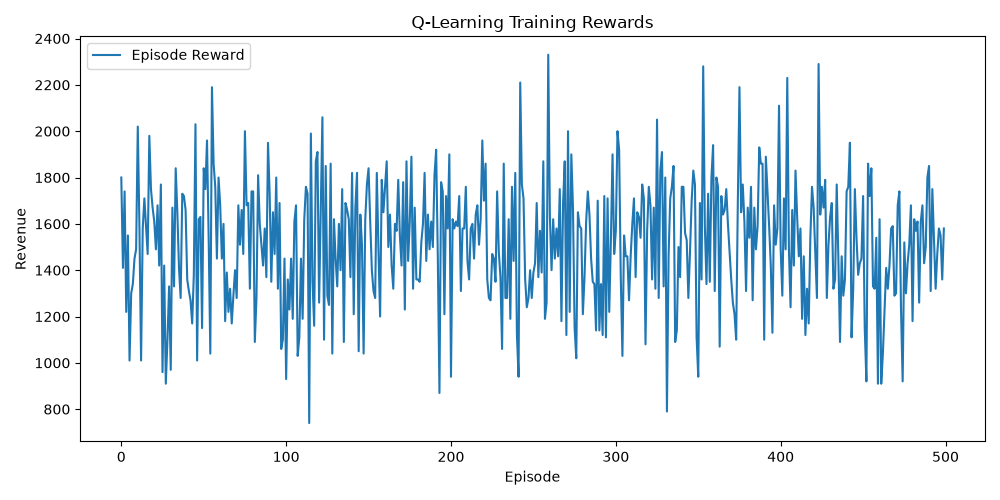

In [10]:
from IPython.display import Image

Image("../outputs/figures/qlearning_training_curve.png")

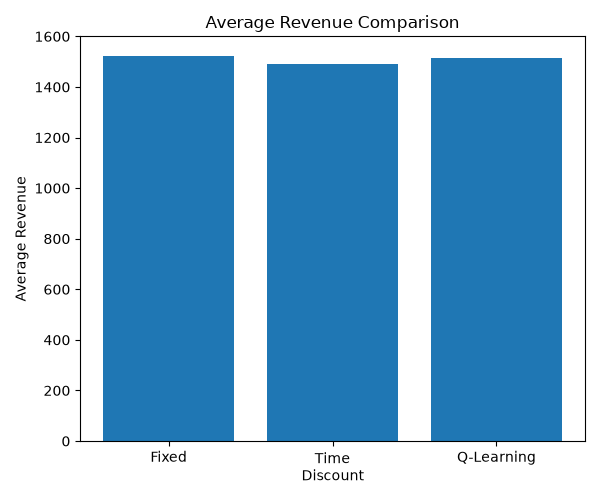

In [11]:
Image("../outputs/figures/revenue_comparison.png")

## Performance Summary

The three pricing approaches were evaluated over multiple simulated booking seasons.

The following metrics summarize their overall performance.

In [14]:
import pandas as pd

metrics = pd.read_csv("../outputs/metrics/evaluation_metrics.csv")

metrics

,Agent,Average Revenue,Std Revenue,Min Revenue,Max Revenue
0,Fixed Price,1516.0,265.977443,700,2100
1,Time Discount,1449.6,274.174835,960,2160
2,Q-Learning,1516.9,252.890075,780,2070


# Conclusion

The Week 2 implementation demonstrates the successful application of tabular Q-Learning to the dynamic pricing problem.

Key outcomes include:

- Developed heuristic baseline strategies for comparison.
- Implemented a Q-Learning agent with epsilon-greedy exploration.
- Trained the agent using the Bellman update equation.
- Evaluated the learned pricing policy against heuristic approaches.
- Visualized training behavior and revenue performance.

Although the current simulation environment is intentionally simplified, the reinforcement learning framework establishes a strong foundation for extending the project using Deep Q-Networks (DQN) in Week 3.